In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

from firedrake.checkpointing import DumbCheckpoint

from firedrake import *

%matplotlib widget

# 1. Load the necessary data

### 1.1 Borehole locations

In [2]:
### Load boreholes
borehole_locations = pd.read_csv('Borehole_Locations/Borehole_locations_DTS.csv')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
transformed_x, transformed_y = transformer.transform(borehole_locations['E'], borehole_locations['S'])

### 1.2 LIMA image

In [3]:
with rasterio.open('imagery/LIMA_virtual_Mosaic_15m.tif') as src1:
    image_data = src1.read()

### 1.3 GPS velocities

In [ ]:
gps_velocities = pd.read_csv('GPS_velocities/24-25_velocities-good.csv')
apres_points = pd.read_csv('ApRES/apres_points.csv')

#### Outline of the area of the good dem

In [5]:
### Load the outline of the good dem

with rasterio.open('Meshes/good_dem_outline/ian_bed_outline_raster_full.tif') as src_good_dem:
    good_dem_filter = src_good_dem.read(2)

### 1.4 Model flow field

#### 1.4.1 First we need to create the same mesh/function space that this was saved on

I am just getting this directly from "scripts/model_runner.py"

The cell below loads the DEMs and creates an extrudede mesh from them which we then can make a function space from to put the loaded flow field.

#### 1.4.1.1 Coarse mesh

In [6]:
# upscale_factor_coarse = 1/100
# src_bed_coarse = rasterio.open("Meshes/ThreeD_meshing/bedmachine_ian_merged_bed_large_aoi_8m_aligned_fixed.tif")
# src_surf_coarse = rasterio.open("Meshes/ThreeD_meshing/rema_large_aoi_align_fixed.tif")

# src_bed = src_bed_coarse
# src_surf = src_surf_coarse



# bed_DEM = src_bed.read(1,
#                         out_shape=(
#                             src_bed.count,
#                             int(src_bed.height * upscale_factor_coarse),
#                             int(src_bed.width * upscale_factor_coarse)
#                         ),
#                         resampling=Resampling.bilinear
#                     )

# # scale image transform
# src_bed_transform = src_bed.transform * src_bed.transform.scale(
#     (src_bed.width / bed_DEM.shape[-1]),
#     (src_bed.height / bed_DEM.shape[-2])
# )

# surf_DEM = src_surf.read(1,
#                         out_shape=(
#                             src_surf.count,
#                             int(src_surf.height * upscale_factor_coarse),
#                             int(src_surf.width * upscale_factor_coarse)
#                         ),
#                         resampling=Resampling.bilinear
#                     )

# # scale image transform
# src_surf_transform = src_surf.transform * src_surf.transform.scale(
#     (src_surf.width / surf_DEM.shape[-1]),
#     (src_surf.height / surf_DEM.shape[-2])
# )

# ### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


# thickness = surf_DEM - bed_DEM
# thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
# zero_offset = copy.deepcopy(thickness)
# zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
# bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM

# height = surf_DEM.shape[0]
# width = surf_DEM.shape[1]
# cols, rows = np.meshgrid(np.arange(width), np.arange(height))
# xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
# lons= np.array(xs)
# lats = np.array(ys)

# surf_elevs = surf_DEM.flatten()
# bed_elevs = bed_DEM.flatten()

# """
# Create a unite fine mesh to interpolate the coarse model results onto.
# """

# layers = 5 # number of layers in z direction of the extruded mesh
# nx = width - 1
# ny = height - 1

# Lx = lons.max() # x extent, get this from the DEM
# Ly = lats.max() # y extent, get this from the DEM

# origin_x = lons.min() # origin (lower left corner) in x, get this from the DEM
# origin_y = lats.min() # origin (lower left corner) in y, get this from the DEM

# base_mesh = RectangleMesh(nx,ny, Lx, Ly, originX=origin_x, originY=origin_y)

# unit_extruded_mesh = ExtrudedMesh(base_mesh, layers=layers)

# xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh

# base_fs = FunctionSpace(base_mesh, "CG", 1)

# x,y, = SpatialCoordinate(base_mesh)

# # You could set this field any way you like.
# ## Bed and surface DEM resolution should be nx+1, ny+1 as to match the coordinates of the mesh.

# # Now we transfer the bathymetry field into a depth-averaged field.
# extruded_element = FiniteElement("R", "interval", 0)
# extruded_space = FunctionSpace(unit_extruded_mesh,
#                                 TensorProductElement(base_fs.ufl_element(),
#                                                     extruded_element))


# from scipy.interpolate import griddata
# ## interpolate the DEMs to the mesh coordinates so it is given in the mesh coordinate order
# points = np.array([xs,ys]).T # DEM pixel coordinates
# xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh
# surf_interp = griddata(points, surf_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)
# bed_interp = griddata(points, bed_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)

# ## Extrude the bed and surface
# extruded_bed = Function(extruded_space)
# extruded_bed.dat.data_wo[:] = bed_interp

# extruded_surface = Function(extruded_space)
# extruded_surface.dat.data_wo[:] = surf_interp

# # Build a new coordinate field by change of coordinates.
# x, y, z = SpatialCoordinate(unit_extruded_mesh)
# new_coordinates = assemble(
#     interpolate(
#         as_vector([x, y, (1-z) * extruded_bed + z * extruded_surface]),
#         unit_extruded_mesh.coordinates.function_space()
#     )
# )


# # Finally build the mesh you are actually after.
# mesh_coarse = Mesh(new_coordinates) # Mesh(new_coordinates, tolerance=50)
# x_coarse, y_coarse, z_coarse = SpatialCoordinate(mesh_coarse)


In [7]:
# pressure_space = firedrake.FunctionSpace(mesh_coarse, "CG", 1)
# velocity_space = firedrake.VectorFunctionSpace(mesh_coarse, "CG", 3)
# Y = velocity_space * pressure_space
# flow = firedrake.Function(Y)

In [8]:
# chk = DumbCheckpoint("Saved_Models/coarse_mesh_flow", mode=FILE_READ)
# chk.load(flow, name="coarse_mesh_flow")

#### 1.4.1.2 Fine mesh

In [9]:
upscale_factor_fine = 1/10
src_bed_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif")
src_surf_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif")
src_bed = src_bed_fine
src_surf = src_surf_fine

bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor_fine),
                            int(src_bed.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor_fine),
                            int(src_surf.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
lons= np.array(xs)
lats = np.array(ys)

surf_elevs = surf_DEM.flatten()
bed_elevs = bed_DEM.flatten()

"""
Create a unite fine mesh to interpolate the coarse model results onto.
"""

layers = 5 # number of layers in z direction of the extruded mesh
nx = width - 1
ny = height - 1

Lx = lons.max() # x extent, get this from the DEM
Ly = lats.max() # y extent, get this from the DEM

origin_x = lons.min() # origin (lower left corner) in x, get this from the DEM
origin_y = lats.min() # origin (lower left corner) in y, get this from the DEM

base_mesh = RectangleMesh(nx,ny, Lx, Ly, originX=origin_x, originY=origin_y)

unit_extruded_mesh = ExtrudedMesh(base_mesh, layers=layers)

xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh

base_fs = FunctionSpace(base_mesh, "CG", 1)

x,y, = SpatialCoordinate(base_mesh)

# You could set this field any way you like.
## Bed and surface DEM resolution should be nx+1, ny+1 as to match the coordinates of the mesh.

# Now we transfer the bathymetry field into a depth-averaged field.
extruded_element = FiniteElement("R", "interval", 0)
extruded_space = FunctionSpace(unit_extruded_mesh,
                                TensorProductElement(base_fs.ufl_element(),
                                                    extruded_element))


from scipy.interpolate import griddata
## interpolate the DEMs to the mesh coordinates so it is given in the mesh coordinate order
points = np.array([xs,ys]).T # DEM pixel coordinates
xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh
surf_interp = griddata(points, surf_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)
bed_interp = griddata(points, bed_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)

## Extrude the bed and surface
extruded_bed = Function(extruded_space)
extruded_bed.dat.data_wo[:] = bed_interp

extruded_surface = Function(extruded_space)
extruded_surface.dat.data_wo[:] = surf_interp

# Build a new coordinate field by change of coordinates.
x, y, z = SpatialCoordinate(unit_extruded_mesh)
new_coordinates = assemble(
    interpolate(
        as_vector([x, y, (1-z) * extruded_bed + z * extruded_surface]),
        unit_extruded_mesh.coordinates.function_space()
    )
)


# Finally build the mesh you are actually after.
mesh_fine = Mesh(new_coordinates) # Mesh(new_coordinates, tolerance=50)
x_fine, y_fine, z_fine = SpatialCoordinate(mesh_fine)


/opt/firedrake/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


In [10]:
pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

In [11]:
chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


/tmp/ipykernel_1373546/482954503.py:157: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_tick_labels)
/tmp/ipykernel_1373546/482954503.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(y_tick_labels)
/tmp/ipykernel_1373546/482954503.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


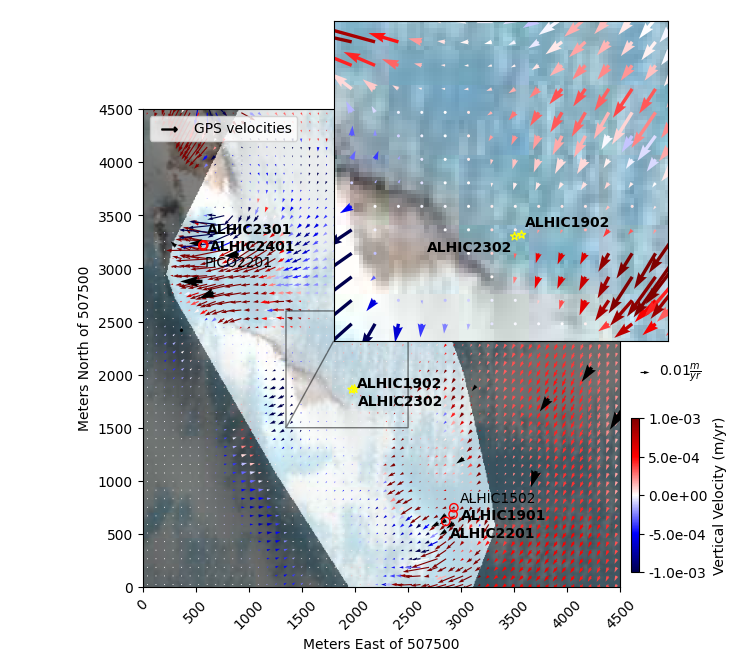

In [94]:


m_above_bed = 10

fig, axes = plt.subplots(figsize=[9 * 5/6,8 *5/6])


vel_cross = []
vel_cross_coords = []

### If the DEM includes some nonesense pixels in it, you need this block ##########
# for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
#     if 1998.99 < z_coord < 1999.01:
#         continue
#     else:
#         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
#         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
#####################################################################################

### If the DEM is perfectly rectangular, than you can do this block ####
for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    try:
        vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    except:
        vel_cross.append([np.nan, np.nan, np.nan])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        continue

#########################################


vel_cross = np.asarray(vel_cross)
vel_cross_coords = np.asarray(vel_cross_coords)

norm_model = mcolors.Normalize(vmin=-0.001, vmax=0.001)
cmap = plt.cm.seismic
colors_model = cmap(norm_model(vel_cross[:,2]*spy))



show(image_data,ax=axes,transform=src1.transform)




Q = axes.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=None, color=colors_model)

axes.set_xlim([vel_cross_coords[:,0].min()-100, vel_cross_coords[:,0].max()+100])
axes.set_ylim([vel_cross_coords[:,1].min()-100, vel_cross_coords[:,1].max()+100])

# Colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
# sm.set_array([])  # Needed only to satisfy colorbar creation
# cbar = plt.colorbar(sm, ax=axes, fraction=0.026, pad=0.04)
# cbar.set_label('Vertical Velocity (m/yr)')

# import matplotlib.ticker as ticker
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))

### Colorbar for Model ###
cbar_ax = axes.inset_axes([-0.05, .04, 1, .3], xticks=[], yticks=[], facecolor="None") # Example: left, bottom, width, height
sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
cbar = plt.colorbar(sm, ax=cbar_ax, fraction=0.026, pad=0.04)
cbar_ax.spines['left'].set_edgecolor('none')
cbar_ax.spines['right'].set_edgecolor('none')
cbar_ax.spines['top'].set_edgecolor('none')
cbar_ax.spines['bottom'].set_edgecolor('none')
cbar.set_label('Vertical Velocity (m/yr)')
import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))


quiverkey_scale = .01
quiverkey_scale_str = str(quiverkey_scale)




qk = axes.quiverkey(Q, 1.06, 0.45, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

colors_gps = cmap(norm_model(gps_velocities['w']))
axes.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                angles='xy', scale_units='xy', scale=None,
                #color=colors_gps
                )

show(good_dem_filter,ax=axes,transform=src_good_dem.transform,cmap='gray', alpha=0.5)

## Plotting and annotating boreholes ##

axes.scatter(transformed_x[0],transformed_y[0], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+70,transformed_y[0]-50), weight='bold')

axes.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20), weight='bold')

axes.scatter(transformed_x[2],transformed_y[2], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20), weight='bold')

axes.scatter(transformed_x[3],transformed_y[3], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150), weight='bold')

axes.scatter(transformed_x[4],transformed_y[4], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120), weight='bold')

axes.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150), weight='bold')

axes.scatter(transformed_x[6],transformed_y[6], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50), weight='bold')

axes.scatter(transformed_x[7],transformed_y[7], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[7]['Core'], (transformed_x[7]+60,transformed_y[7]+50))

axes.scatter(transformed_x[8],transformed_y[8], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[8]['Core'], (transformed_x[8]+20,transformed_y[8]-200))

axes.scatter([], [], marker=r'$\longrightarrow$', color="black", s=120, label="GPS velocities")
axes.legend(loc='upper left')


axes.set_xlim([507500, 512000])
axes.set_ylim([-1.3555e6, -1.351e6])

axes.xaxis.set_tick_params(rotation=45)


# axes.set_title("Velocity "+str(m_above_bed)+' m Above Bed')
axins = axes.inset_axes(
    [0.4, 0.5, 0.7, 0.7],
    xticks=[], 
    yticks=[]
    )
show(image_data,ax=axins,transform=src1.transform)
Q = axins.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=2e-5, 
                width = 0.01,
                color=colors_model)

axins.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None")
axins.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+10,transformed_y[1]+30), weight='bold')

axins.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None")
axins.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]-300,transformed_y[5]-50), weight='bold')

axins.set_xlim([508850, 510000])
axins.set_ylim([-1.3540e6, -1.3529e6])
axes.indicate_inset_zoom(axins, edgecolor="black")


axes.set_xlabel('Meters East of '+axes.get_xticklabels()[0].get_text())
axes.set_ylabel('Meters North of '+axes.get_xticklabels()[0].get_text())


x_tick_labels = [int(float(item.get_text()) -  float(axes.get_xticklabels()[0].get_text())) for item in axes.get_xticklabels()]
axes.set_xticklabels(x_tick_labels)

y_tick_labels = [int(float(item.get_text().replace('−','-'))*1e6 -  float(axes.get_yticklabels()[0].get_text().replace('−','-'))*1e6) for item in axes.get_yticklabels()]
axes.set_yticklabels(y_tick_labels)


plt.tight_layout()
# plt.savefig('Figures/fig1_updated_80m.eps', dpi=600, bbox_inches='tight', format='eps', transparent=True)
# plt.savefig('Figures/fig1_updated_80m.png', dpi=600, bbox_inches='tight', format='png', transparent=False)



/tmp/ipykernel_1780466/3522926895.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_tick_labels)
/tmp/ipykernel_1780466/3522926895.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(y_tick_labels)
/tmp/ipykernel_1780466/3522926895.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


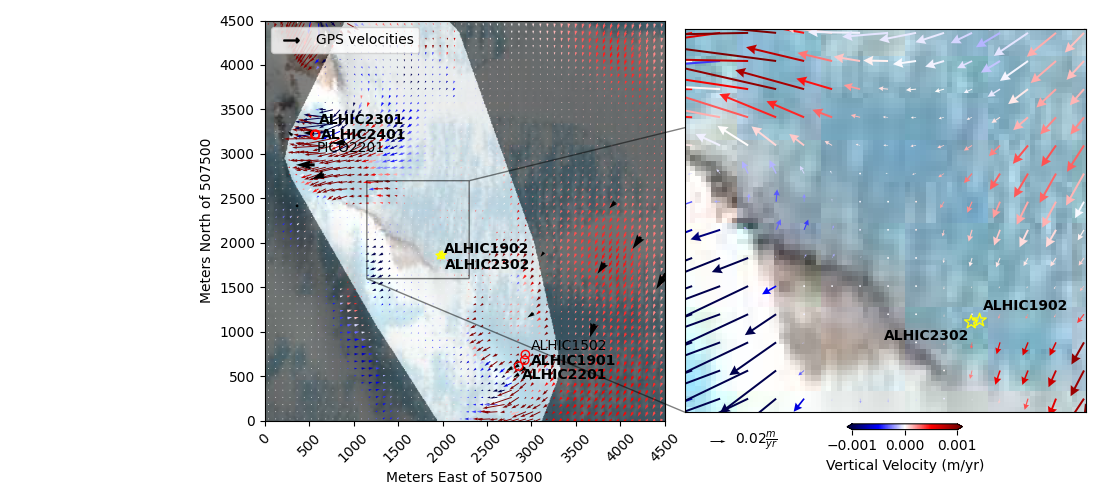

In [24]:
m_above_bed = 10

fig, axes = plt.subplots(figsize=[11,5])


vel_cross = []
vel_cross_coords = []

### If the DEM includes some nonesense pixels in it, you need this block ##########
# for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
#     if 1998.99 < z_coord < 1999.01:
#         continue
#     else:
#         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
#         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
#####################################################################################

### If the DEM is perfectly rectangular, than you can do this block ####
for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    try:
        vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    except:
        vel_cross.append([np.nan, np.nan, np.nan])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        continue

#########################################


vel_cross = np.asarray(vel_cross)
vel_cross_coords = np.asarray(vel_cross_coords)

norm_model = mcolors.Normalize(vmin=-0.001, vmax=0.001)
cmap = plt.cm.seismic
colors_model = cmap(norm_model(vel_cross[:,2]*spy))



show(image_data,ax=axes,transform=src1.transform)




Q = axes.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=None, color=colors_model)

axes.set_xlim([vel_cross_coords[:,0].min()-100, vel_cross_coords[:,0].max()+100])
axes.set_ylim([vel_cross_coords[:,1].min()-100, vel_cross_coords[:,1].max()+100])

# Colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
# sm.set_array([])  # Needed only to satisfy colorbar creation
# cbar = plt.colorbar(sm, ax=axes, fraction=0.026, pad=0.04)
# cbar.set_label('Vertical Velocity (m/yr)')

# import matplotlib.ticker as ticker
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))

### Colorbar for Model ###
cbar_ax = axes.inset_axes([.4, .04, 1, .3], xticks=[], yticks=[], facecolor="None") # Example: left, bottom, width, height
sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
cbar = plt.colorbar(sm, ax=cbar_ax, fraction=0.05, pad=0.04, location='bottom', extend='both')
cbar_ax.spines['left'].set_edgecolor('none')
cbar_ax.spines['right'].set_edgecolor('none')
cbar_ax.spines['top'].set_edgecolor('none')
cbar_ax.spines['bottom'].set_edgecolor('none')
cbar.set_label('Vertical Velocity (m/yr)')
import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))


# quiverkey_scale = .1
# quiverkey_scale_str = str(quiverkey_scale)




# qk = axes.quiverkey(Q, 1.06, 0.45, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

colors_gps = cmap(norm_model(gps_velocities['w']))
axes.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                angles='xy', scale_units='xy', scale=None,
                #color=colors_gps
                )

show(good_dem_filter,ax=axes,transform=src_good_dem.transform,cmap='gray', alpha=0.5)

## Plotting and annotating boreholes ##

axes.scatter(transformed_x[0],transformed_y[0], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+70,transformed_y[0]-50), weight='bold')

axes.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20), weight='bold')

axes.scatter(transformed_x[2],transformed_y[2], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20), weight='bold')

axes.scatter(transformed_x[3],transformed_y[3], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150), weight='bold')

axes.scatter(transformed_x[4],transformed_y[4], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120), weight='bold')

axes.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150), weight='bold')

axes.scatter(transformed_x[6],transformed_y[6], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50), weight='bold')

axes.scatter(transformed_x[7],transformed_y[7], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[7]['Core'], (transformed_x[7]+60,transformed_y[7]+50))

axes.scatter(transformed_x[8],transformed_y[8], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[8]['Core'], (transformed_x[8]+20,transformed_y[8]-200))

axes.scatter([], [], marker=r'$\longrightarrow$', color="black", s=120, label="GPS velocities")
axes.legend(loc='upper left')


axes.set_xlim([507500, 512000])
axes.set_ylim([-1.3555e6, -1.351e6])

axes.xaxis.set_tick_params(rotation=45)


# axes.set_title("Velocity "+str(m_above_bed)+' m Above Bed')
axins = axes.inset_axes(
    [1.05, 0, 1, 1],
    xticks=[], 
    yticks=[]
    )
show(image_data,ax=axins,transform=src1.transform)
Q_in = axins.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=2e-5, 
                width = 0.005,
                color=colors_model, 
                headwidth = 5,
                headlength = 5,
                minshaft = 2)

axins.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None",s=100)
axins.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+10,transformed_y[1]+30), weight='bold')

axins.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None",s=100)
axins.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]-250,transformed_y[5]-50), weight='bold')

axins.set_xlim([508650, 509800])
axins.set_ylim([-1.3539e6, -1.3528e6])
axes.indicate_inset_zoom(axins, edgecolor="black")


quiverkey_scale = .02
quiverkey_scale_str = str(quiverkey_scale)

qk = axes.quiverkey(Q, 1.15, -0.05, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

axes.set_xlabel('Meters East of '+axes.get_xticklabels()[0].get_text())
axes.set_ylabel('Meters North of '+axes.get_xticklabels()[0].get_text())


x_tick_labels = [int(float(item.get_text()) -  float(axes.get_xticklabels()[0].get_text())) for item in axes.get_xticklabels()]
axes.set_xticklabels(x_tick_labels)

y_tick_labels = [int(float(item.get_text().replace('−','-'))*1e6 -  float(axes.get_yticklabels()[0].get_text().replace('−','-'))*1e6) for item in axes.get_yticklabels()]
axes.set_yticklabels(y_tick_labels)


plt.tight_layout()
plt.savefig('Figures/fig1_updated_80m_subplot.eps', dpi=600, bbox_inches='tight', format='eps', transparent=True)
plt.savefig('Figures/fig1_updated_80m_subplot.png', dpi=600, bbox_inches='tight', format='png', transparent=False)

/tmp/ipykernel_1373546/1263480599.py:170: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(x_tick_labels)
/tmp/ipykernel_1373546/1263480599.py:173: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_yticklabels(y_tick_labels)
/tmp/ipykernel_1373546/1263480599.py:176: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


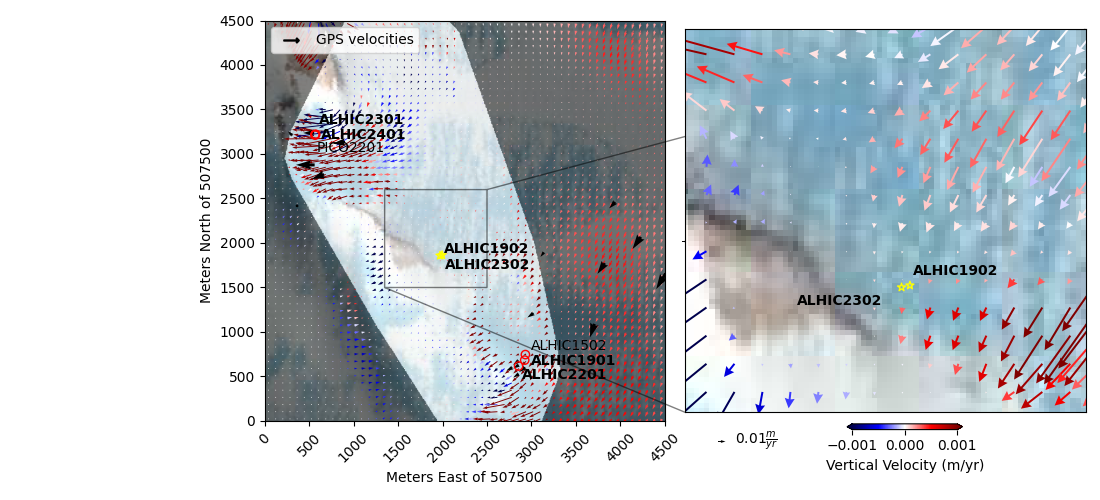

In [131]:
m_above_bed = 10

fig, axes = plt.subplots(figsize=[11,5])


vel_cross = []
vel_cross_coords = []

### If the DEM includes some nonesense pixels in it, you need this block ##########
# for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
#     if 1998.99 < z_coord < 1999.01:
#         continue
#     else:
#         vel_cross.append(y.at(x_coord, y_coord, z_coord+m_above_bed)[0])
#         vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
#####################################################################################

### If the DEM is perfectly rectangular, than you can do this block ####
for x_coord, y_coord, z_coord in zip(xi[:,0], xi[:,1], extruded_bed.dat.data_ro[:]):
    try:
        vel_cross.append(flow.at(x_coord, y_coord, z_coord+m_above_bed)[0])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
    except:
        vel_cross.append([np.nan, np.nan, np.nan])
        vel_cross_coords.append([x_coord, y_coord, z_coord+m_above_bed])
        continue

#########################################


vel_cross = np.asarray(vel_cross)
vel_cross_coords = np.asarray(vel_cross_coords)

norm_model = mcolors.Normalize(vmin=-0.001, vmax=0.001)
cmap = plt.cm.seismic
colors_model = cmap(norm_model(vel_cross[:,2]*spy))



show(image_data,ax=axes,transform=src1.transform)




Q = axes.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=None, color=colors_model)

axes.set_xlim([vel_cross_coords[:,0].min()-100, vel_cross_coords[:,0].max()+100])
axes.set_ylim([vel_cross_coords[:,1].min()-100, vel_cross_coords[:,1].max()+100])

# Colorbar
# sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
# sm.set_array([])  # Needed only to satisfy colorbar creation
# cbar = plt.colorbar(sm, ax=axes, fraction=0.026, pad=0.04)
# cbar.set_label('Vertical Velocity (m/yr)')

# import matplotlib.ticker as ticker
# cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))

### Colorbar for Model ###
cbar_ax = axes.inset_axes([.4, .04, 1, .3], xticks=[], yticks=[], facecolor="None") # Example: left, bottom, width, height
sm = cm.ScalarMappable(cmap=cmap, norm=norm_model)
cbar = plt.colorbar(sm, ax=cbar_ax, fraction=0.05, pad=0.04, location='bottom', extend='both')
cbar_ax.spines['left'].set_edgecolor('none')
cbar_ax.spines['right'].set_edgecolor('none')
cbar_ax.spines['top'].set_edgecolor('none')
cbar_ax.spines['bottom'].set_edgecolor('none')
cbar.set_label('Vertical Velocity (m/yr)')
import matplotlib.ticker as ticker
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))


quiverkey_scale = .01
quiverkey_scale_str = str(quiverkey_scale)




qk = axes.quiverkey(Q, 1.06, 0.45, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

colors_gps = cmap(norm_model(gps_velocities['w']))
axes.quiver(gps_velocities['x'], gps_velocities['y'], 
                gps_velocities['u'], gps_velocities['v'], 
                angles='xy', scale_units='xy', scale=None,
                #color=colors_gps
                )

show(good_dem_filter,ax=axes,transform=src_good_dem.transform,cmap='gray', alpha=0.5)

## Plotting and annotating boreholes ##

axes.scatter(transformed_x[0],transformed_y[0], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[0]['Core'], (transformed_x[0]+70,transformed_y[0]-50), weight='bold')

axes.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+20,transformed_y[1]+20), weight='bold')

axes.scatter(transformed_x[2],transformed_y[2], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[2]['Core'], (transformed_x[2]+20,transformed_y[2]+20), weight='bold')

axes.scatter(transformed_x[3],transformed_y[3], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[3]['Core'], (transformed_x[3]+40,transformed_y[3]-150), weight='bold')

axes.scatter(transformed_x[4],transformed_y[4], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[4]['Core'], (transformed_x[4]+40,transformed_y[4]+120), weight='bold')

axes.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None")
axes.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]+60,transformed_y[5]-150), weight='bold')

axes.scatter(transformed_x[6],transformed_y[6], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[6]['Core'], (transformed_x[6]+60,transformed_y[6]-50), weight='bold')

axes.scatter(transformed_x[7],transformed_y[7], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[7]['Core'], (transformed_x[7]+60,transformed_y[7]+50))

axes.scatter(transformed_x[8],transformed_y[8], marker='o',ec='red', fc="None")
axes.annotate(borehole_locations.iloc()[8]['Core'], (transformed_x[8]+20,transformed_y[8]-200))

axes.scatter([], [], marker=r'$\longrightarrow$', color="black", s=120, label="GPS velocities")
axes.legend(loc='upper left')


axes.set_xlim([507500, 512000])
axes.set_ylim([-1.3555e6, -1.351e6])

axes.xaxis.set_tick_params(rotation=45)


# axes.set_title("Velocity "+str(m_above_bed)+' m Above Bed')
axins = axes.inset_axes(
    [1.05, 0, 1, 1],
    xticks=[], 
    yticks=[]
    )
show(image_data,ax=axins,transform=src1.transform)

# for locs,arrows in zip(vel_cross_coords, vel_cross):
#     axins.annotate("h", (locs[0],locs[1]))#, xycoords = 'data', xytext=(locs[0]+arrows[0],locs[1]+arrows[1]), arrowprops={'arrowstyle':'->'})


Q_in = axins.quiver(vel_cross_coords[:,0], vel_cross_coords[:,1], vel_cross[:,0]*spy, vel_cross[:,1]*spy, 
                angles='xy', scale_units='xy', scale=2e-5, 
                width = 0.005,
                color=colors_model, 
                headwidth = 5,
                headlength = 5,
                minlength = 0.0001)

axins.scatter(transformed_x[1],transformed_y[1], marker='*',ec='yellow', fc="None")
axins.annotate(borehole_locations.iloc()[1]['Core'], (transformed_x[1]+10,transformed_y[1]+30), weight='bold')

axins.scatter(transformed_x[5],transformed_y[5], marker='*',ec='yellow', fc="None")
axins.annotate(borehole_locations.iloc()[5]['Core'], (transformed_x[5]-300,transformed_y[5]-50), weight='bold')

axins.set_xlim([508850, 510000])
axins.set_ylim([-1.3540e6, -1.3529e6])
axes.indicate_inset_zoom(axins, edgecolor="black")


quiverkey_scale = .01
quiverkey_scale_str = str(quiverkey_scale)

qk = axes.quiverkey(Q, 1.15, -0.05, quiverkey_scale, quiverkey_scale_str+r'$\frac{m}{yr}$', labelpos='E', coordinates='axes', color='black')

axes.set_xlabel('Meters East of '+axes.get_xticklabels()[0].get_text())
axes.set_ylabel('Meters North of '+axes.get_xticklabels()[0].get_text())


x_tick_labels = [int(float(item.get_text()) -  float(axes.get_xticklabels()[0].get_text())) for item in axes.get_xticklabels()]
axes.set_xticklabels(x_tick_labels)

y_tick_labels = [int(float(item.get_text().replace('−','-'))*1e6 -  float(axes.get_yticklabels()[0].get_text().replace('−','-'))*1e6) for item in axes.get_yticklabels()]
axes.set_yticklabels(y_tick_labels)


plt.tight_layout()
# plt.savefig('Figures/fig1_updated_80m_subplot.eps', dpi=600, bbox_inches='tight', format='eps', transparent=True)
# plt.savefig('Figures/fig1_updated_80m_subplot.png', dpi=600, bbox_inches='tight', format='png', transparent=False)

In [22]:
apres_points

,Unnamed: 0,Name,Lat,Lon,x,y,u,v,w,Horizontal uncertainty,Vertical uncertainty,stake_height_change
0,GPS-Track4-3,Track 4-3,-76.706100,159.279083,513269.870190,-1356831.374,-0.153444,-0.273525,0.0281,0.0067,0.0293,0.031413
1,GPS-Track5-3,Track 5-3,-76.741742,159.249983,512569.068527,-1352901.961,-0.112801,-0.137335,-0.0169,0.0067,0.0302,0.021000
2,GPS-Xd,Xd,-76.752008,159.107978,515517.830419,-1350571.976,0.157189,-0.411809,-0.0728,0.0065,0.0293,0.010550
3,GPS-Track4-9,Track 4-9,-76.744924,159.117823,515563.637685,-1351388.962,0.161600,-0.423583,-0.0909,0.0073,0.0318,-0.084413
4,GPS-Track4-5,Track 4-5,-76.716084,159.210052,514514.174479,-1355184.547,-0.111594,-0.290954,-0.0490,0.0091,0.0416,0.024438
5,GPS-Track5-2,Track 5-2,-76.739940,159.288546,511728.527356,-1353432.145,-0.095721,-0.139146,-0.0139,0.0067,0.0294,0.008000
6,GPS-Track4-6,Track 4-6,-76.722194,159.182248,514932.790977,-1354306.212,-0.059456,-0.336524,-0.0772,0.0079,0.0327,0.008450
7,GPS-Track4-10,Track 4-10,-76.753687,159.107413,515465.221813,-1350394.219,0.172415,-0.431016,0.0177,0.0067,0.0299,-0.049575
8,GPS-Track5-6,Track 5-6,-76.746555,159.133535,515129.079858,-1351362.552,0.115924,-0.376408,-0.0304,0.0077,0.0332,-0.054000
9,GPS-Track4-8,Track 4-8,-76.736909,159.137563,515412.127229,-1352390.724,0.111003,-0.356572,-0.0201,0.0073,0.0307,-0.038363


In [13]:
z_coords = np.linspace(extruded_bed.dat.data_ro[:].min(), extruded_bed.dat.data_ro[:].max(), 100)

vel_profiles = {}

for x_coord, y_coord, i in zip(transformed_x, transformed_y, borehole_locations.iloc()):
    
    vel_prof = []
    vel_prof_coords = []

    core_name = i['Core']
    
    hor_u_prof = []
    hor_v_prof = []

    ver_profile = []

    for z_coord in z_coords:
        try:
            velocity = flow.at(x_coord, y_coord, z_coord)[0]*spy
            vel_prof.append(velocity)
            hor_u_prof.append(velocity[0])
            hor_v_prof.append(velocity[1])
            ver_profile.append(velocity[2])
            vel_prof_coords.append([x_coord, y_coord, z_coord])
        except:
            continue
    try:
        vel_profiles[core_name] = [np.array(vel_prof_coords)[:,-1],hor_u_prof, hor_v_prof, ver_profile]
    except:
        continue

ALHIC1901 avg hor vel: -0.006335369531937691 avg ver vel: -0.00579431554053327
ALHIC1902 avg hor vel: -0.00036938681368144495 avg ver vel: -0.0011770687293799682
ALHIC2201 avg hor vel: -0.005460310069931322 avg ver vel: -0.004941091153845315
ALHIC2301 avg hor vel: -0.06032362784935277 avg ver vel: 0.015310359376864677
ALHIC2302 avg hor vel: -0.0002919212443155954 avg ver vel: -0.0009902762532646024
ALHIC2401 avg hor vel: -0.06244290578650085 avg ver vel: 0.014941230890064756
ALHIC1502 avg hor vel: -0.007586729776921419 avg ver vel: -0.005586737559543185
PICO2201 avg hor vel: -0.058474716002062416 avg ver vel: 0.015226202816306465


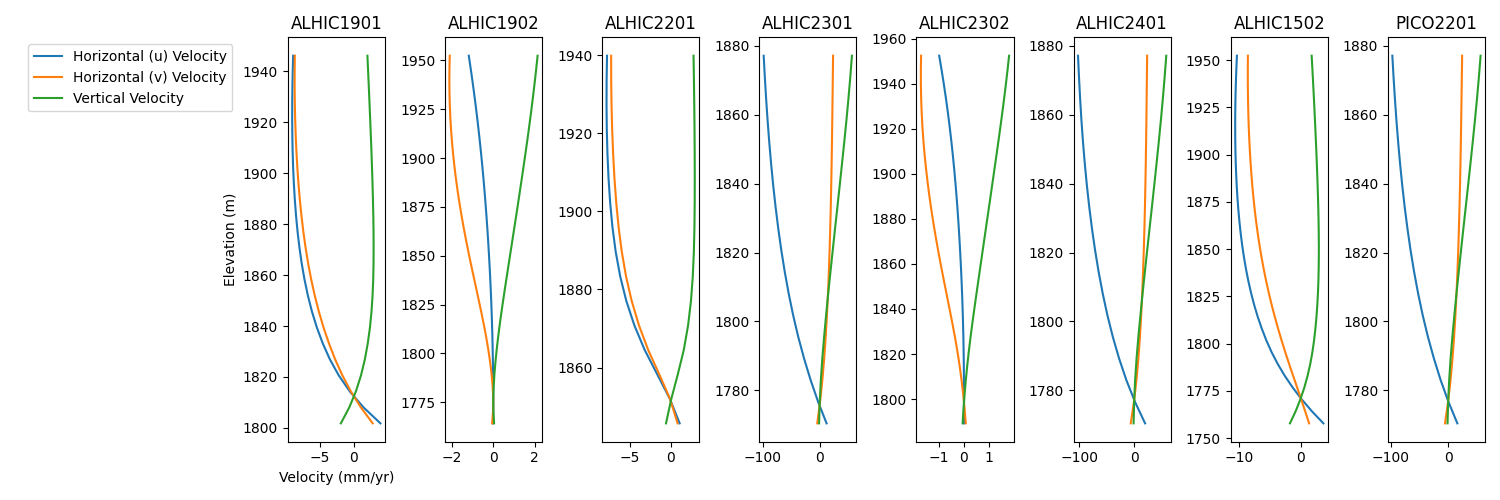

In [17]:
fig,ax = plt.subplots(1,len(vel_profiles), figsize=[15,5])

for n,i in enumerate(vel_profiles):

    ax[n].plot(np.array(vel_profiles[i][1])*1000, vel_profiles[i][0], label='Horizontal (u) Velocity')
    ax[n].plot(np.array(vel_profiles[i][2])*1000, vel_profiles[i][0], label='Horizontal (v) Velocity')
    ax[n].plot(np.array(vel_profiles[i][3])*1000, vel_profiles[i][0], label='Vertical Velocity')
    ax[n].set_title(i)
    # ax[n].set_xlim([-0.002,0.1])
    avg_hor = np.mean(vel_profiles[i][1])
    avg_ver = np.mean(vel_profiles[i][2])
    print(i + ' avg hor vel: ' + str(avg_hor) + ' avg ver vel: ' + str(avg_ver))

ax[0].legend(bbox_to_anchor=(-.5, 1))


ax[0].set_ylabel('Elevation (m)')
ax[0].set_xlabel('Velocity (mm/yr)')

plt.tight_layout()

In [30]:
vel_profiles['PICO2201'][0][-1] - vel_profiles['PICO2201'][0][0]

np.float64(106.67115982105292)

In [34]:
z_coords = np.linspace(extruded_bed.dat.data_ro[:].min(), extruded_bed.dat.data_ro[:].max(), 100)

vel_profiles = {}

for x_coord, y_coord, i in zip(apres_points['x'].values, apres_points['y'].values, apres_points.iloc()):
    
    vel_prof = []
    vel_prof_coords = []

    site_name = i['Name']
    
    hor_prof = []
    ver_profile = []

    for z_coord in z_coords:
        try:
            velocity = flow.at(x_coord, y_coord, z_coord)[0]*spy
            vel_prof.append(velocity)
            hor_prof.append(np.sqrt(velocity[0]**2 + velocity[1]**2))
            ver_profile.append(velocity[2])
            vel_prof_coords.append([x_coord, y_coord, z_coord])
        except:
            continue
    try:
        vel_profiles[site_name] = [np.array(vel_prof_coords)[:,-1],hor_prof,ver_profile]
    except:
        continue

In [58]:
site_name = list(vel_profiles.keys())[0]

In [59]:
vel_profiles

{'Track 5-2': [array([1437.86704236, 1444.14181647, 1450.41659058, 1456.69136468,
         1462.96613879, 1469.2409129 , 1475.51568701, 1481.79046111,
         1488.06523522, 1494.34000933, 1500.61478343, 1506.88955754,
         1513.16433165, 1519.43910576, 1525.71387986, 1531.98865397,
         1538.26342808, 1544.53820218, 1550.81297629, 1557.0877504 ,
         1563.3625245 , 1569.63729861, 1575.91207272, 1582.18684683,
         1588.46162093, 1594.73639504, 1601.01116915, 1607.28594325,
         1613.56071736, 1619.83549147, 1626.11026558, 1632.38503968,
         1638.65981379, 1644.9345879 , 1651.209362  , 1657.48413611,
         1663.75891022, 1670.03368433, 1676.30845843, 1682.58323254,
         1688.85800665, 1695.13278075, 1701.40755486, 1707.68232897,
         1713.95710308, 1720.23187718, 1726.50665129, 1732.7814254 ,
         1739.0561995 , 1745.33097361, 1751.60574772, 1757.88052183,
         1764.15529593, 1770.43007004, 1776.70484415, 1782.97961825,
         1789.2543923

Track 5-2 avg hor vel: 0.015945978451973684 avg ver vel: -0.004807702993136926


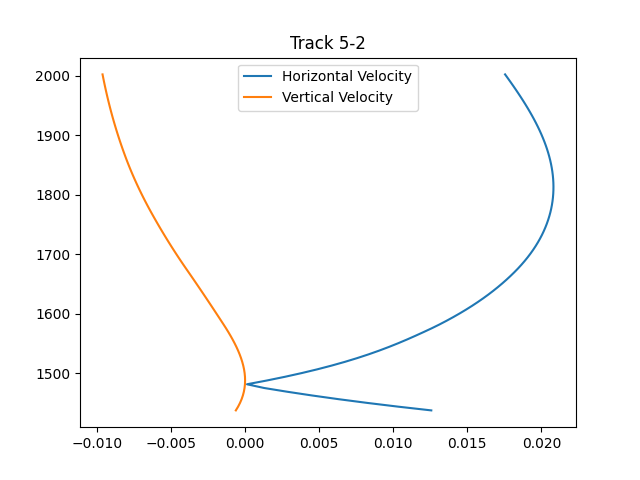

In [61]:
fig,ax = plt.subplots(1,len(vel_profiles))



ax.plot(vel_profiles[site_name][1], vel_profiles[site_name][0], label='Horizontal Velocity')
ax.plot(vel_profiles[site_name][2], vel_profiles[site_name][0], label='Vertical Velocity')
ax.set_title(site_name)
# ax[n].set_xlim([-0.002,0.1])
avg_hor = np.mean(vel_profiles[site_name][1])
avg_ver = np.mean(vel_profiles[site_name][2])
print(i + ' avg hor vel: ' + str(avg_hor) + ' avg ver vel: ' + str(avg_ver))
plt.legend()


### Compare against GPS measurements

In [15]:
z_coords = np.linspace(extruded_bed.dat.data_ro[:].min(), extruded_bed.dat.data_ro[:].max(), 100)

residuals = {}
uncertainties = {}
velocities = {}
model_velocities = {}


for i in gps_velocities.iloc():
    x_coord, y_coord = i['x'], i['y']
    GPS_surf_u, GPS_surf_v, GPS_surf_w = i['u'], i['v'], i['w']
    vel_prof = []
    vel_prof_coords = []
    hor_uncertain = i["Horizontal uncertainty"]
    ver_uncertain = i["Vertical uncertainty"]


    hor_prof = []
    ver_profile = []

    for z_coord in z_coords:
        try:
            velocity = flow.at(x_coord, y_coord, z_coord)[0]*spy
            vel_prof.append(velocity)
            hor_prof.append(np.sqrt(velocity[0]**2 + velocity[1]**2))
            ver_profile.append(velocity[2])
            vel_prof_coords.append([x_coord, y_coord, z_coord])
        except:
            continue
    try:
        vel_profiles[core_name] = [np.array(vel_prof_coords)[:,-1],hor_prof,ver_profile]
    except:
        continue
    
    model_surf_u, model_surf_v, model_surf_w = vel_prof[-1]
    
    residual_u = GPS_surf_u - model_surf_u
    residual_v = GPS_surf_v - model_surf_v
    residual_w = GPS_surf_w - model_surf_w

    residuals[i['Name']] = [residual_u, residual_v, residual_w]
    uncertainties[i['Name']] = [hor_uncertain, ver_uncertain]
    velocities[i['Name']] = GPS_surf_u, GPS_surf_v, GPS_surf_w
    model_velocities[i['Name']] = model_surf_u, model_surf_v, model_surf_w
    

In [16]:
gps_names = list(residuals.keys())

u_residual = np.array(list(residuals.values()))[:,0]
v_residual = np.array(list(residuals.values()))[:,1]
w_residual = np.array(list(residuals.values()))[:,2]

u_uncertainty = np.array(list(uncertainties.values()))[:,0]
v_uncertainty = np.array(list(uncertainties.values()))[:,0]
w_uncertainty = np.array(list(uncertainties.values()))[:,1]

u_GPS_vel = np.array(list(velocities.values()))[:,0]
v_GPS_vel = np.array(list(velocities.values()))[:,1]
w_GPS_vel = np.array(list(velocities.values()))[:,2]

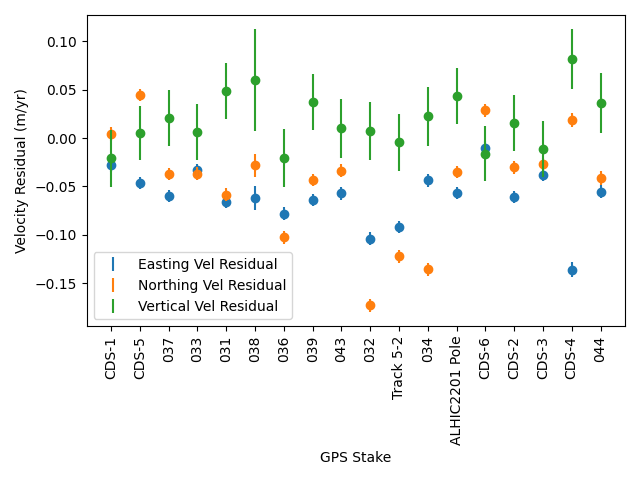

In [ ]:
fig,ax = plt.subplots()

ax.scatter(gps_names, u_residual)
ax.scatter(gps_names, v_residual)
ax.scatter(gps_names, w_residual)

ax.errorbar(gps_names, u_residual, yerr=u_uncertainty,linestyle="None", label='Easting Vel Residual')
ax.errorbar(gps_names, v_residual, yerr=v_uncertainty,linestyle="None", label='Northing Vel Residual')
ax.errorbar(gps_names, w_residual, yerr=w_uncertainty,linestyle="None", label='Vertical Vel Residual')

ax.tick_params(axis='x', labelrotation=90)

ax.set_ylabel('Velocity Residual (m/yr)')
ax.set_xlabel('GPS Stake')

plt.legend()
plt.tight_layout()

80.93103155766723
382.0271011310011
117.63842169316032


Text(0, 0.5, 'Velocity Residual (% of GPS Velocity)')

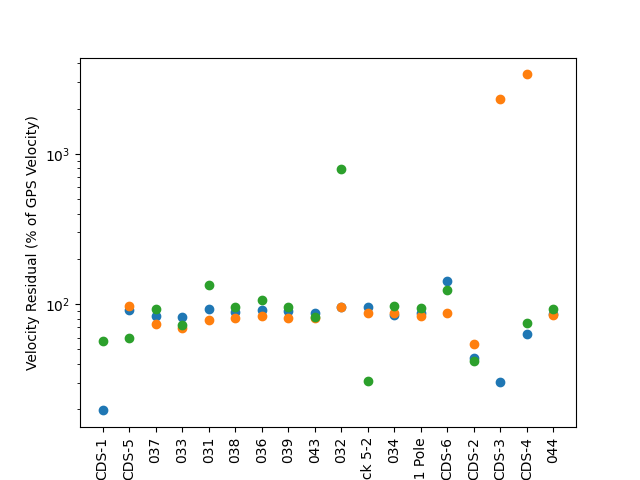

In [201]:
fig, ax = plt.subplots()

ax.scatter(gps_names, (u_residual/u_GPS_vel)*100)
ax.scatter(gps_names, (v_residual/v_GPS_vel)*100)
ax.scatter(gps_names, (w_residual/w_GPS_vel)*100)

print(np.average((u_residual/u_GPS_vel)*100))
print(np.average((v_residual/v_GPS_vel)*100))
print(np.average((w_residual/w_GPS_vel)*100))

ax.set_yscale('log')
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel('Velocity Residual (% of GPS Velocity)')

In [202]:
u_model = np.array(list(model_velocities.values()))[:,0]
v_model = np.array(list(model_velocities.values()))[:,1]
w_model = np.array(list(model_velocities.values()))[:,2]

In [206]:
theta_GPS = np.arctan2(v_GPS_vel, u_GPS_vel) * (180/np.pi)
theta_model = np.arctan2(v_model, u_model) * (180/np.pi)

theta_GPS_fix = []
theta_model_fix = []
for th_GPS, th_model in zip(theta_GPS, theta_model):
    if th_GPS < 0:
        new_GPS = th_GPS+360
        theta_GPS_fix.append(new_GPS)
    else:
        theta_GPS_fix.append(th_GPS)
    if th_model < 0:
        new_model = th_model+360
        theta_model_fix.append(new_model)
    else:
        theta_model_fix.append(th_model)

theta_GPS_fix = np.array(theta_GPS_fix)
theta_model_fix = np.array(theta_model_fix)

In [210]:
np.average(np.abs(theta_GPS_fix - theta_model_fix))

np.float64(14.226429726393828)

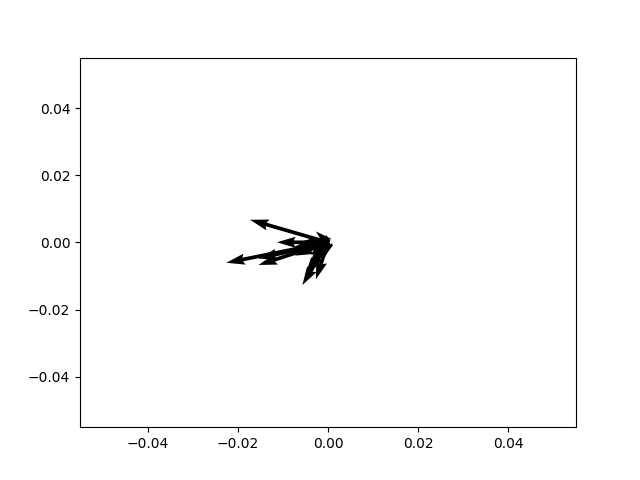

In [ ]:
fig,ax = plt.subplots()
ax.quiver([0]*len(u_model), [0]*len(u_model), u_model, v_model)
ax.quiver([0]*len(u_GPS_vel), [0]*len(u_GPS_vel), u_GPS_vel, v_GPS_vel)

In [186]:
print(np.average(np.sqrt(u_model**2+v_model**2+w_model**2)))

print(np.average(np.sqrt(u_GPS_vel**2+v_GPS_vel**2+w_GPS_vel**2)))

mag_diff = np.average(np.sqrt(u_model**2+v_model**2+w_model**2)) - np.average(np.sqrt(u_GPS_vel**2+v_GPS_vel**2+w_GPS_vel**2))

print(mag_diff)

0.0329137953888462
0.1221482804360925
-0.08923448504724629
